# Fail2Drive result analysis

This notebook reads `results/<run>/<seed>/res/*_res.json`, identifies each route's scenario family from `fail2drive_split`, and compares Base with Generalization. A positive **degradation** means the Generalization average is lower than Base.

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', context='notebook')

# Run this notebook from the fail2drive directory, or adjust PROJECT_ROOT.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'results').exists():
    PROJECT_ROOT = PROJECT_ROOT / 'fail2drive'

RESULTS_ROOT = PROJECT_ROOT / 'results'
SPLIT_ROOT = PROJECT_ROOT / 'fail2drive_split'

# Set RUNS to a list such as ['hipad', 'hipad_oracle_new_2']; use None for every run.
RUNS = ['transfuser', 'transfuser_oracle']
SEEDS = [1]  # Use None for every available seed.
FINISHED_ONLY = True

assert RESULTS_ROOT.exists(), f'Missing results directory: {RESULTS_ROOT}'
assert SPLIT_ROOT.exists(), f'Missing split directory: {SPLIT_ROOT}'


In [2]:
ROUTE_RE = re.compile(r'^(Base|Generalization)_(.+)_(\d{4})\.xml$')

route_metadata = {}
for route_path in SPLIT_ROOT.glob('*.xml'):
    match = ROUTE_RE.match(route_path.name)
    if not match:
        continue
    split, family, case_id = match.groups()
    route_metadata[case_id] = {
        'split': split,
        'family': family,
        'route_file': route_path.name,
    }

def number_or_none(value):
    return None if value is None else float(value)

rows = []
for result_path in RESULTS_ROOT.glob('*/*/res/*_res.json'):
    # .../results/<run>/<seed>/res/<case>_res.json
    run, seed = result_path.parents[2].name, result_path.parents[1].name
    if RUNS is not None and run not in RUNS:
        continue
    if SEEDS is not None and seed not in {str(item) for item in SEEDS}:
        continue
    case_id = result_path.stem.removesuffix('_res')
    with result_path.open() as handle:
        result = json.load(handle)
    record = result.get('_checkpoint', {}).get('global_record', {})
    score = record.get('scores_mean', {})
    infractions = record.get('infractions', {})
    rows.append({
        'run': run, 'seed': int(seed), 'case_id': case_id,
        'entry_status': result.get('entry_status'), 'eligible': result.get('eligible'),
        'record_status': record.get('status'),
        'driving_score': number_or_none(score.get('score_composed')),
        'route_completion': number_or_none(score.get('score_route')),
        'infraction_penalty': number_or_none(score.get('score_penalty')),
        'collisions_vehicle': number_or_none(infractions.get('collisions_vehicle')),
        'collisions_pedestrian': number_or_none(infractions.get('collisions_pedestrian')),
        'collisions_layout': number_or_none(infractions.get('collisions_layout')),
        'min_speed_infractions': number_or_none(infractions.get('min_speed_infractions')),
        **route_metadata.get(case_id, {'split': 'Unknown', 'family': 'Unknown', 'route_file': None}),
    })

results = pd.DataFrame(rows)
assert not results.empty, 'No result JSON files matched the selected RUNS and SEEDS.'
results = results.sort_values(['run', 'seed', 'case_id']).reset_index(drop=True)
results.head()


,run,seed,case_id,entry_status,eligible,record_status,driving_score,route_completion,infraction_penalty,collisions_vehicle,collisions_pedestrian,collisions_layout,min_speed_infractions,split,family,route_file
0,transfuser,1,0000,Finished,True,Perfect,100.000000,100.0,1.000000,0.00,0.0,0.0,0.000,Base,BadParking,Base_BadParking_0000.xml
1,transfuser,1,0001,Finished,True,Perfect,100.000000,100.0,1.000000,0.00,0.0,0.0,0.000,Base,BadParking,Base_BadParking_0001.xml
2,transfuser,1,0002,Finished,True,Completed,83.581577,100.0,0.835816,0.00,0.0,0.0,14.991,Base,BadParking,Base_BadParking_0002.xml
3,transfuser,1,0003,Finished,True,Completed,94.421220,100.0,0.944212,0.00,0.0,0.0,5.811,Base,BadParking,Base_BadParking_0003.xml
4,transfuser,1,0004,Finished,True,Completed,30.182460,100.0,0.301825,2.55,0.0,0.0,2.550,Base,BadParking,Base_BadParking_0004.xml


In [3]:
# Verify completeness before comparing metrics.
completeness = (results.groupby(['run', 'seed'])
    .agg(cases=('case_id', 'size'),
         finished=('entry_status', lambda s: (s == 'Finished').sum()),
         eligible=('eligible', 'sum'),
         base_cases=('split', lambda s: (s == 'Base').sum()),
         generalization_cases=('split', lambda s: (s == 'Generalization').sum()))
    .reset_index())
display(completeness)

analysis = results.copy()
if FINISHED_ONLY:
    analysis = analysis.query("entry_status == 'Finished' and eligible == True").copy()

print(f'Analysing {len(analysis)} finished, eligible route results.')
unfinished = results.query("entry_status != 'Finished' or eligible != True")
display(unfinished[['run', 'seed', 'case_id', 'route_file', 'entry_status', 'eligible']])


,run,seed,cases,finished,eligible,base_cases,generalization_cases
0,transfuser,1,198,198,198,100,98
1,transfuser_oracle,1,200,199,199,100,100


Analysing 397 finished, eligible route results.


,run,seed,case_id,route_file,entry_status,eligible
314,transfuser_oracle,1,1016,Generalization_ConstructionPermutations_1016.xml,Started,False


In [4]:
METRICS = ['driving_score', 'route_completion', 'infraction_penalty']

# Overall Base vs Generalization summary for every run/seed.
split_summary = (analysis.groupby(['run', 'seed', 'split'])[METRICS]
    .mean().join(analysis.groupby(['run', 'seed', 'split']).size().rename('n'))
    .reset_index())
display(split_summary.sort_values(['run', 'seed', 'split']))

# Per-family comparison. Positive degradation means Generalization < Base.
family_summary = (analysis.groupby(['run', 'seed', 'family', 'split'])[METRICS]
    .mean().join(analysis.groupby(['run', 'seed', 'family', 'split']).size().rename('n'))
    .reset_index())

wide = family_summary.pivot(index=['run', 'seed', 'family'], columns='split', values=METRICS + ['n'])
wide.columns = [f'{metric}_{split.lower()}' for metric, split in wide.columns]
wide = wide.reset_index()
for metric in METRICS:
    wide[f'{metric}_degradation'] = wide[f'{metric}_base'] - wide[f'{metric}_generalization']

degradation_columns = ['run', 'seed', 'family', 'n_base', 'n_generalization'] + [
    f'{metric}_{suffix}' for metric in METRICS for suffix in ('base', 'generalization', 'degradation')
]
degradation = wide[degradation_columns].sort_values(['run', 'seed', 'driving_score_degradation'], ascending=[True, True, False])
display(degradation.round(3))


,run,seed,split,driving_score,route_completion,infraction_penalty,n
0,transfuser,1,Base,83.735486,99.180000,0.839397,100
1,transfuser,1,Generalization,77.368949,98.787959,0.775065,98
2,transfuser_oracle,1,Base,86.968533,99.731700,0.869803,100
3,transfuser_oracle,1,Generalization,81.326191,98.737475,0.816787,99


,run,seed,family,n_base,n_generalization,driving_score_base,driving_score_generalization,driving_score_degradation,route_completion_base,route_completion_generalization,route_completion_degradation,infraction_penalty_base,infraction_penalty_generalization,infraction_penalty_degradation
16,transfuser,1,Wall,5.0,5.0,98.986,63.641,35.345,100.000,100.000,0.000,0.990,0.636,0.353
13,transfuser,1,PedestriansOnRoad,5.0,5.0,97.073,66.297,30.776,100.000,100.000,0.000,0.971,0.663,0.308
1,transfuser,1,BadParking,10.0,10.0,89.944,66.734,23.210,100.000,100.000,0.000,0.899,0.667,0.232
5,transfuser,1,FullyBlocked,5.0,5.0,99.182,82.413,16.768,100.000,100.000,0.000,0.992,0.824,0.168
2,transfuser,1,ConstructionPedestrian,5.0,5.0,66.321,50.655,15.666,91.432,85.772,5.660,0.671,0.521,0.150
4,transfuser,1,CustomObstacles,10.0,10.0,62.706,50.605,12.102,96.084,95.236,0.848,0.644,0.512,0.131
14,transfuser,1,RightConstruction,5.0,5.0,99.144,88.903,10.241,100.000,100.000,0.000,0.991,0.889,0.102
9,transfuser,1,OppositeConstruction,5.0,5.0,99.996,92.731,7.265,100.000,100.000,0.000,1.000,0.927,0.073
3,transfuser,1,ConstructionPermutations,5.0,3.0,38.467,31.783,6.684,100.000,100.000,0.000,0.385,0.318,0.067
8,transfuser,1,ObscuredStop,5.0,5.0,100.000,100.000,0.000,100.000,100.000,0.000,1.000,1.000,0.000


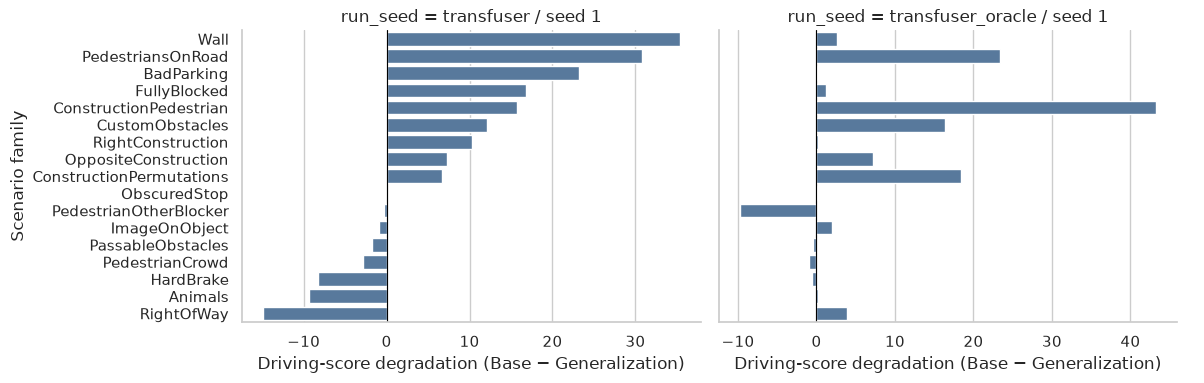

In [5]:
# Plot score degradation for each family. Positive bars are worse on Generalization.
plot_data = degradation.dropna(subset=['driving_score_degradation']).copy()
plot_data['run_seed'] = plot_data['run'] + ' / seed ' + plot_data['seed'].astype(str)

g = sns.catplot(
    data=plot_data, kind='bar', x='driving_score_degradation', y='family',
    col='run_seed', col_wrap=2, sharex=False, height=4, aspect=1.5, color='#4c78a8'
)
g.set_axis_labels('Driving-score degradation (Base − Generalization)', 'Scenario family')
for axis in g.axes.flat:
    axis.axvline(0, color='black', linewidth=0.8)
plt.show()


run,transfuser,transfuser_oracle
seed,1,1
family,,
Animals,97.14,96.65
BadParking,66.73,75.91
ConstructionPedestrian,50.66,42.71
ConstructionPermutations,31.78,26.80
CustomObstacles,50.60,54.77
FullyBlocked,82.41,97.25
HardBrake,74.50,79.21
ImageOnObject,90.51,84.98


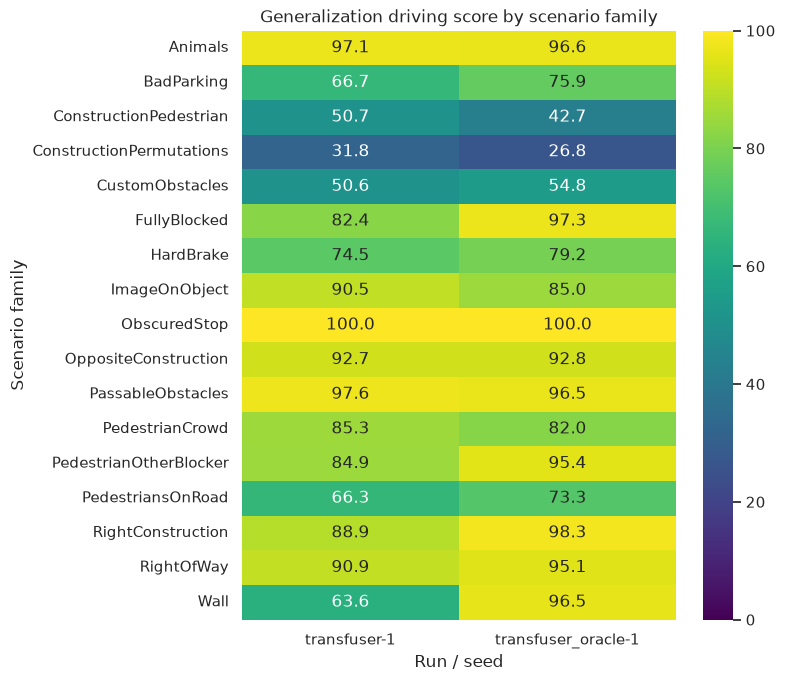

In [6]:
# Compare selected runs directly on the Generalization split.
generalization_by_run = (analysis.query("split == 'Generalization'")
    .groupby(['run', 'seed', 'family'])[METRICS].mean()
    .reset_index())

score_heatmap = generalization_by_run.pivot_table(
    index='family', columns=['run', 'seed'], values='driving_score'
).sort_index()
display(score_heatmap.round(2))

plt.figure(figsize=(max(7, 2 * len(score_heatmap.columns)), max(5, 0.45 * len(score_heatmap))))
sns.heatmap(score_heatmap, annot=True, fmt='.1f', cmap='viridis', vmin=0, vmax=100)
plt.title('Generalization driving score by scenario family')
plt.xlabel('Run / seed')
plt.ylabel('Scenario family')
plt.show()


Paired completed routes: 198
Ignored abs(delta) < 5: 136 | included: 62
Oracle improved: 36 | degraded: 26 | tied: 0
Mean driving-score delta (oracle − vanilla): +12.787


,route_file,driving_score_vanilla,driving_score_oracle,driving_score_delta,route_completion_vanilla,route_completion_oracle,infraction_penalty_vanilla,infraction_penalty_oracle
case_id,,,,,,,,
0009,Base_BadParking_0009.xml,97.429,37.242,-60.187,100.0,100.00,0.974,0.372
1014,Generalization_ConstructionPedestrian_1014.xml,95.342,43.563,-51.778,100.0,100.00,0.953,0.436
1026,Generalization_CustomObstacles_1026.xml,98.644,54.722,-43.922,100.0,100.00,0.986,0.547
0005,Base_BadParking_0005.xml,100.000,61.892,-38.108,100.0,100.00,1.000,0.619
1005,Generalization_BadParking_1005.xml,100.000,62.912,-37.088,100.0,100.00,1.000,0.629
1006,Generalization_BadParking_1006.xml,100.000,64.484,-35.516,100.0,100.00,1.000,0.645
1010,Generalization_ConstructionPedestrian_1010.xml,95.356,60.000,-35.356,100.0,100.00,0.954,0.600
0008,Base_BadParking_0008.xml,93.829,58.509,-35.320,100.0,100.00,0.938,0.585
0023,Base_CustomObstacles_0023.xml,87.361,52.069,-35.292,100.0,100.00,0.874,0.521


,route_file,driving_score_vanilla,driving_score_oracle,driving_score_delta,route_completion_vanilla,route_completion_oracle,infraction_penalty_vanilla,infraction_penalty_oracle
case_id,,,,,,,,
0013,Base_ConstructionPedestrian_0013.xml,5.301,100.000,94.699,57.16,100.0,0.093,1.000
1029,Generalization_CustomObstacles_1029.xml,6.941,84.940,77.999,52.36,100.0,0.133,0.849
0055,Base_RightOfWay_0055.xml,25.200,100.000,74.800,100.00,100.0,0.252,1.000
0020,Base_CustomObstacles_0020.xml,6.226,77.821,71.595,100.00,100.0,0.062,0.778
1001,Generalization_BadParking_1001.xml,36.000,100.000,64.000,100.00,100.0,0.360,1.000
1003,Generalization_BadParking_1003.xml,32.348,89.873,57.525,100.00,100.0,0.323,0.899
0024,Base_CustomObstacles_0024.xml,38.745,96.109,57.364,100.00,100.0,0.387,0.961
0015,Base_ConstructionPermutations_0015.xml,31.228,83.233,52.005,100.00,100.0,0.312,0.832
0075,Base_Animals_0075.xml,50.000,99.856,49.856,100.00,100.0,0.500,0.999


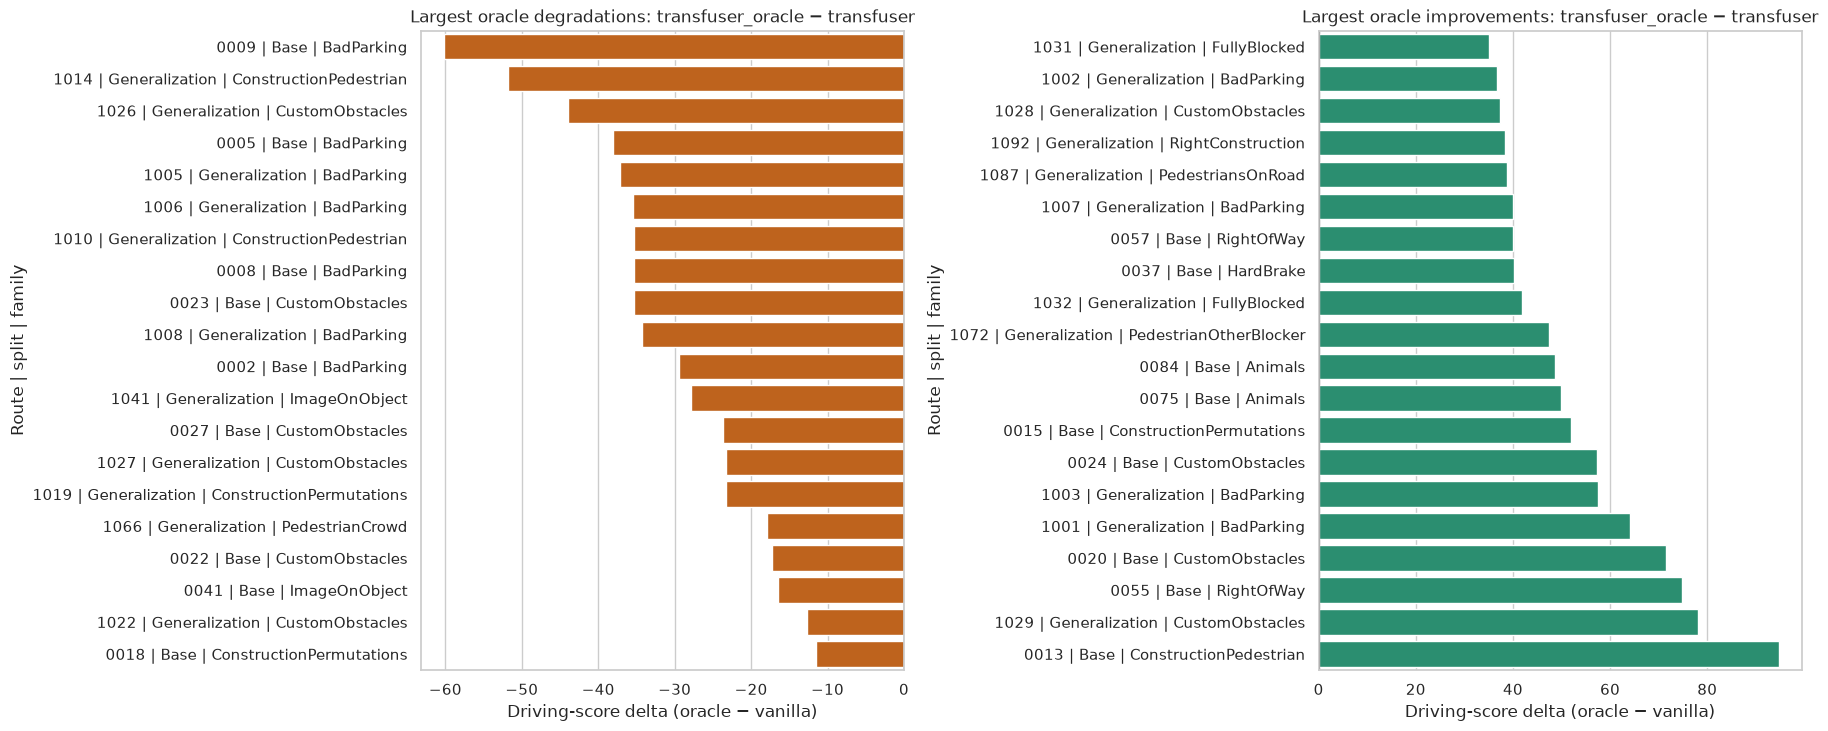

In [7]:
# Route-level vanilla vs oracle comparison.
# Change ORACLE_RUN to compare a different oracle experiment.
VANILLA_RUN = 'transfuser'
ORACLE_RUN = 'transfuser_oracle'
COMPARE_SEED = 1
TOP_N = 20
MIN_ABS_SCORE_DELTA = 5.0  # Ignore route changes smaller than this threshold.

pair_source = analysis.query('seed == @COMPARE_SEED and run in [@VANILLA_RUN, @ORACLE_RUN]')
metadata_columns = ['case_id', 'route_file', 'split', 'family']
metric_columns = ['driving_score', 'route_completion', 'infraction_penalty']
vanilla = (pair_source.query('run == @VANILLA_RUN')[metadata_columns + metric_columns]
    .drop_duplicates('case_id').set_index('case_id'))
oracle = (pair_source.query('run == @ORACLE_RUN')[['case_id'] + metric_columns]
    .drop_duplicates('case_id').set_index('case_id'))
route_comparison = vanilla.join(oracle, how='inner', lsuffix='_vanilla', rsuffix='_oracle')
for metric in metric_columns:
    route_comparison[f'{metric}_delta'] = route_comparison[f'{metric}_oracle'] - route_comparison[f'{metric}_vanilla']
route_comparison['route_label'] = route_comparison.index + ' | ' + route_comparison['split'] + ' | ' + route_comparison['family']

meaningful_comparison = route_comparison.loc[route_comparison['driving_score_delta'].abs() >= MIN_ABS_SCORE_DELTA].copy()
score_delta = meaningful_comparison['driving_score_delta']
print(f'Paired completed routes: {len(route_comparison)}')
print(f'Ignored abs(delta) < {MIN_ABS_SCORE_DELTA:g}: {len(route_comparison) - len(meaningful_comparison)} | included: {len(meaningful_comparison)}')
print(f'Oracle improved: {(score_delta > 0).sum()} | degraded: {(score_delta < 0).sum()} | tied: {(score_delta == 0).sum()}')
print(f'Mean driving-score delta (oracle − vanilla): {score_delta.mean():+.3f}')

display_columns = ['route_file', 'driving_score_vanilla', 'driving_score_oracle', 'driving_score_delta', 'route_completion_vanilla', 'route_completion_oracle', 'infraction_penalty_vanilla', 'infraction_penalty_oracle']
display(meaningful_comparison.sort_values('driving_score_delta')[display_columns].round(3).head(TOP_N))
display(meaningful_comparison.sort_values('driving_score_delta', ascending=False)[display_columns].round(3).head(TOP_N))

worst = meaningful_comparison.nsmallest(TOP_N, 'driving_score_delta').sort_values('driving_score_delta')
best = meaningful_comparison.nlargest(TOP_N, 'driving_score_delta').sort_values('driving_score_delta')
fig, axes = plt.subplots(1, 2, figsize=(18, max(6, TOP_N * 0.36)), constrained_layout=True)
sns.barplot(data=worst, x='driving_score_delta', y='route_label', ax=axes[0], color='#d95f02')
sns.barplot(data=best, x='driving_score_delta', y='route_label', ax=axes[1], color='#1b9e77')
axes[0].set_title(f'Largest oracle degradations: {ORACLE_RUN} − {VANILLA_RUN}')
axes[1].set_title(f'Largest oracle improvements: {ORACLE_RUN} − {VANILLA_RUN}')
for axis in axes:
    axis.axvline(0, color='black', linewidth=0.8)
    axis.set_xlabel('Driving-score delta (oracle − vanilla)')
    axis.set_ylabel('Route | split | family')
plt.show()


In [8]:
# Route-level inspection: use this to investigate the largest regressions.
route_columns = ['run', 'seed', 'case_id', 'route_file', 'split', 'family'] + METRICS + [
    'collisions_vehicle', 'collisions_pedestrian', 'collisions_layout', 'min_speed_infractions'
] # route_file
worst_routes = analysis.sort_values('driving_score')[route_columns].head(30)
display(worst_routes.round(3))

# Optional exports for reports.
# degradation.to_csv(PROJECT_ROOT / 'results_base_vs_generalization.csv', index=False)
# results.to_csv(PROJECT_ROOT / 'results_route_level.csv', index=False)


,run,seed,case_id,route_file,split,family,driving_score,route_completion,infraction_penalty,collisions_vehicle,collisions_pedestrian,collisions_layout,min_speed_infractions
118,transfuser,1,1020,Generalization_CustomObstacles_1020.xml,Generalization,CustomObstacles,0.002,100.00,0.000,0.000,0.000,139.546,0.000
317,transfuser_oracle,1,1019,Generalization_ConstructionPermutations_1019.xml,Generalization,ConstructionPermutations,1.373,76.86,0.018,4.364,0.000,30.548,13.092
217,transfuser_oracle,1,0019,Base_ConstructionPermutations_0019.xml,Base,ConstructionPermutations,3.215,73.17,0.044,4.584,0.000,22.920,9.168
111,transfuser,1,1011,Generalization_ConstructionPedestrian_1011.xml,Generalization,ConstructionPedestrian,3.304,65.91,0.050,20.758,0.000,5.189,0.000
318,transfuser_oracle,1,1020,Generalization_CustomObstacles_1020.xml,Generalization,CustomObstacles,3.885,38.58,0.101,0.000,0.000,57.873,14.468
383,transfuser_oracle,1,1085,Generalization_PedestriansOnRoad_1085.xml,Generalization,PedestriansOnRoad,4.153,100.00,0.042,6.228,9.342,0.000,6.228
13,transfuser,1,0013,Base_ConstructionPedestrian_0013.xml,Base,ConstructionPedestrian,5.301,57.16,0.093,13.502,0.000,13.502,6.751
19,transfuser,1,0019,Base_ConstructionPermutations_0019.xml,Base,ConstructionPermutations,5.867,100.00,0.059,3.354,0.000,16.771,10.063
20,transfuser,1,0020,Base_CustomObstacles_0020.xml,Base,CustomObstacles,6.226,100.00,0.062,22.327,0.000,0.000,11.164
127,transfuser,1,1029,Generalization_CustomObstacles_1029.xml,Generalization,CustomObstacles,6.941,52.36,0.133,16.745,0.000,0.000,5.582


In [9]:
# Routes where both vanilla and oracle perform poorly.
BAD_SCORE_THRESHOLD = 50.0
TOP_N = 30

both_poor = route_comparison.loc[
    (route_comparison['driving_score_vanilla'] <= BAD_SCORE_THRESHOLD) &
    (route_comparison['driving_score_oracle'] <= BAD_SCORE_THRESHOLD)
].copy()

both_poor['mean_driving_score'] = (
    both_poor['driving_score_vanilla'] + both_poor['driving_score_oracle']
) / 2

display_columns = [
    'route_file', 'split', 'family',
    'driving_score_vanilla', 'driving_score_oracle',
    'driving_score_delta', 'mean_driving_score',
    'route_completion_vanilla', 'route_completion_oracle',
    'infraction_penalty_vanilla', 'infraction_penalty_oracle',
]

display(
    both_poor.sort_values('mean_driving_score')
    [display_columns]
    .head(TOP_N)
    .round(3)
)

,route_file,split,family,driving_score_vanilla,driving_score_oracle,driving_score_delta,mean_driving_score,route_completion_vanilla,route_completion_oracle,infraction_penalty_vanilla,infraction_penalty_oracle
case_id,,,,,,,,,,,
1020,Generalization_CustomObstacles_1020.xml,Generalization,CustomObstacles,0.002,3.885,3.883,1.943,100.00,38.58,0.000,0.101
0019,Base_ConstructionPermutations_0019.xml,Base,ConstructionPermutations,5.867,3.215,-2.652,4.541,100.00,73.17,0.059,0.044
1085,Generalization_PedestriansOnRoad_1085.xml,Generalization,PedestriansOnRoad,7.195,4.153,-3.042,5.674,100.00,100.00,0.072,0.042
1019,Generalization_ConstructionPermutations_1019.xml,Generalization,ConstructionPermutations,24.638,1.373,-23.266,13.005,100.00,76.86,0.246,0.018
1011,Generalization_ConstructionPedestrian_1011.xml,Generalization,ConstructionPedestrian,3.304,30.000,26.696,16.652,65.91,100.00,0.050,0.300
1013,Generalization_ConstructionPedestrian_1013.xml,Generalization,ConstructionPedestrian,9.275,30.000,20.725,19.638,62.95,100.00,0.147,0.300
1017,Generalization_ConstructionPermutations_1017.xml,Generalization,ConstructionPermutations,10.710,36.000,25.290,23.355,100.00,100.00,0.107,0.360
0018,Base_ConstructionPermutations_0018.xml,Base,ConstructionPermutations,39.000,27.462,-11.538,33.231,100.00,100.00,0.390,0.275
1022,Generalization_CustomObstacles_1022.xml,Generalization,CustomObstacles,41.580,28.871,-12.709,35.225,100.00,100.00,0.416,0.289
